# CEIA - Probabilidad y Estadística - Examen final

Codigo: https://github.com/uqee/ceia-probabilidad-y-estadistica

Siguiendo con la historia de Don Francisco, con el tiempo y gracias a los análisis de Matías, el pequeño comerciante de barrio cuenta hoy con 5 supermercados: ’Santa Ana’, ’La Floresta’, ’Los Cedros’, ’Palermo’ y ’Córdoba’.

También Matías ha avanzado en la Especialización en Inteligencia Artificial. Un día Don Francisco le plantea algunas inquietudes adicionales:

1. Don Francisco quiere entender mejor la afluencia de clientes por mes del supermercado ’Santa Ana’.
2. Más aún, Don Francisco no sabe si puede estar seguro de que la afluencia de clientes son las mismas en todos los supermercados o si hay alguno que se comporte mejor que los demás, y si alguna de las tiendas necesita más atención porque está recibiendo menos clientes que las de las otras.

Con base en lo anterior,

In [32]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. (2.5 puntos) Simulación de los clientes diarios

Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro λt debe ser la suma de los siguientes efectos:

### Efecto anual:

| Año  | Efecto |
| ---- | ------ |
| 2023 | 1000   |
| 2024 | 1500   |
| 2025 | 2000   |

### Efecto mensual:

| Mes        | Efecto |
| ---------- | ------ |
| Enero      | 1000   |
| Febrero    | 1500   |
| Marzo      | 2000   |
| Abril      | 2000   |
| Mayo       | 2500   |
| Junio      | 2500   |
| Julio      | 3000   |
| Agosto     | 2500   |
| Septiembre | 2500   |
| Octubre    | 2000   |
| Noviembre  | 1500   |
| Diciembre  | 1000   |

### Efecto diario:

| Dia       | Efecto |
| --------- | ------ |
| Domingo   | 1000   |
| Lunes     | 2000   |
| Martes    | 3000   |
| Miércoles | 3500   |
| Jueves    | 3000   |
| Viernes   | 2000   |
| Sábado    | 1000   |

### Efecto por tienda:

| Tienda      | Efecto |
| ----------- | ------ |
| Santa Ana   | 5000   |
| La Floresta | 2000   |
| Los Cedros  | 3000   |
| Palermo     | 1000   |
| Córdoba     | 3000   |

In [33]:
# Poisson(λ_t), λ_t = efecto_anual + efecto_mensual + efecto_diario + efecto_tienda

ANIO_INICIO = 2023
ANIO_FIN = 2025

EFECTO_ANUAL = {
    2023: 1000,
    2024: 1500,
    2025: 2000
}

MESES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

EFECTO_MENSUAL = {
    1: 1000,
    2: 1500,
    3: 2000,
    4: 2000,
    5: 2500,
    6: 2500,
    7: 3000,
    8: 2500,
    9: 2500,
    10: 2000,
    11: 1500,
    12: 1000,
}

# pandas: 0 = lunes, ..., 6 = domingo
DIAS_SEMANA = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

EFECTO_DIARIO = {
    0: 2000,
    1: 3000,
    2: 3500,
    3: 3000,
    4: 2000,
    5: 1000,
    6: 1000
}

EFECTO_TIENDA = {
    "Santa Ana": 5000,
    "La Floresta": 2000,
    "Los Cedros": 3000,
    "Palermo": 1000,
    "Córdoba": 3000,
}

TIENDAS = tuple(EFECTO_TIENDA)

In [34]:
def simular_clientes(*, seed=42):
    """Clientes diarios de cada tienda, cada uno un Poisson(λ_t)."""
    rng = np.random.default_rng(seed)
    fechas = pd.date_range(f"{ANIO_INICIO}-01-01", f"{ANIO_FIN}-12-31", freq="D")

    fecha_col, tienda_col, lambda_col, clientes_col = [], [], [], []
    for fecha in fechas:
        anio, mes, dia_semana = fecha.year, fecha.month, fecha.dayofweek
        for tienda in TIENDAS:
            lam = (
                EFECTO_ANUAL[anio]
                + EFECTO_MENSUAL[mes]
                + EFECTO_DIARIO[dia_semana]
                + EFECTO_TIENDA[tienda]
            )
            fecha_col.append(fecha)
            tienda_col.append(tienda)
            lambda_col.append(lam)
            clientes_col.append(int(rng.poisson(lam)))

    df = pd.DataFrame(
        {
            "fecha": fecha_col,
            "tienda": tienda_col,
            "lambda_t": lambda_col,
            "clientes": clientes_col,
        }
    )
    df["anio"] = df["fecha"].dt.year
    df["mes"] = df["fecha"].dt.month
    df["dia_semana"] = df["fecha"].dt.dayofweek
    df["nombre_mes"] = df["mes"].map(MESES)
    df["nombre_dia"] = df["dia_semana"].map(DIAS_SEMANA)
    return df

df = simular_clientes(seed=42)
df.head()

,fecha,tienda,lambda_t,clientes,anio,mes,dia_semana,nombre_mes,nombre_dia
0,2023-01-01,Santa Ana,8000,8076,2023,1,6,Enero,Domingo
1,2023-01-01,La Floresta,5000,5087,2023,1,6,Enero,Domingo
2,2023-01-01,Los Cedros,6000,5878,2023,1,6,Enero,Domingo
3,2023-01-01,Palermo,4000,4051,2023,1,6,Enero,Domingo
4,2023-01-01,Córdoba,6000,5899,2023,1,6,Enero,Domingo


In [35]:
print(f"Días simulados  : {df['fecha'].nunique()}")
print(f"Tiendas         : {len(TIENDAS)}")
print(f"Observaciones   : {len(df)}")
print(f"Rango de fechas : {df['fecha'].min().date()} a {df['fecha'].max().date()}")

print("\nPromedio de clientes por año:")
print(df.groupby("anio")["clientes"].mean().round(2))

print("\nAfluencia mensual de 'Santa Ana' (clientes promedio por día):")
print(
    df.loc[df["tienda"] == "Santa Ana"]
    .groupby("nombre_mes")["clientes"]
    .mean()
    .round(2)
)

Días simulados  : 1096
Tiendas         : 5
Observaciones   : 5480
Rango de fechas : 2023-01-01 a 2025-12-31

Promedio de clientes por año:
anio
2023    8012.40
2024    8514.92
2025    9020.51
Name: clientes, dtype: float64

Afluencia mensual de 'Santa Ana' (clientes promedio por día):
nombre_mes
Abril         10722.57
Agosto        11220.40
Diciembre      9710.06
Enero          9748.75
Febrero       10215.85
Julio         11741.48
Junio         11174.34
Marzo         10673.53
Mayo          11252.61
Noviembre     10194.23
Octubre       10734.99
Septiembre    11179.73
Name: clientes, dtype: float64


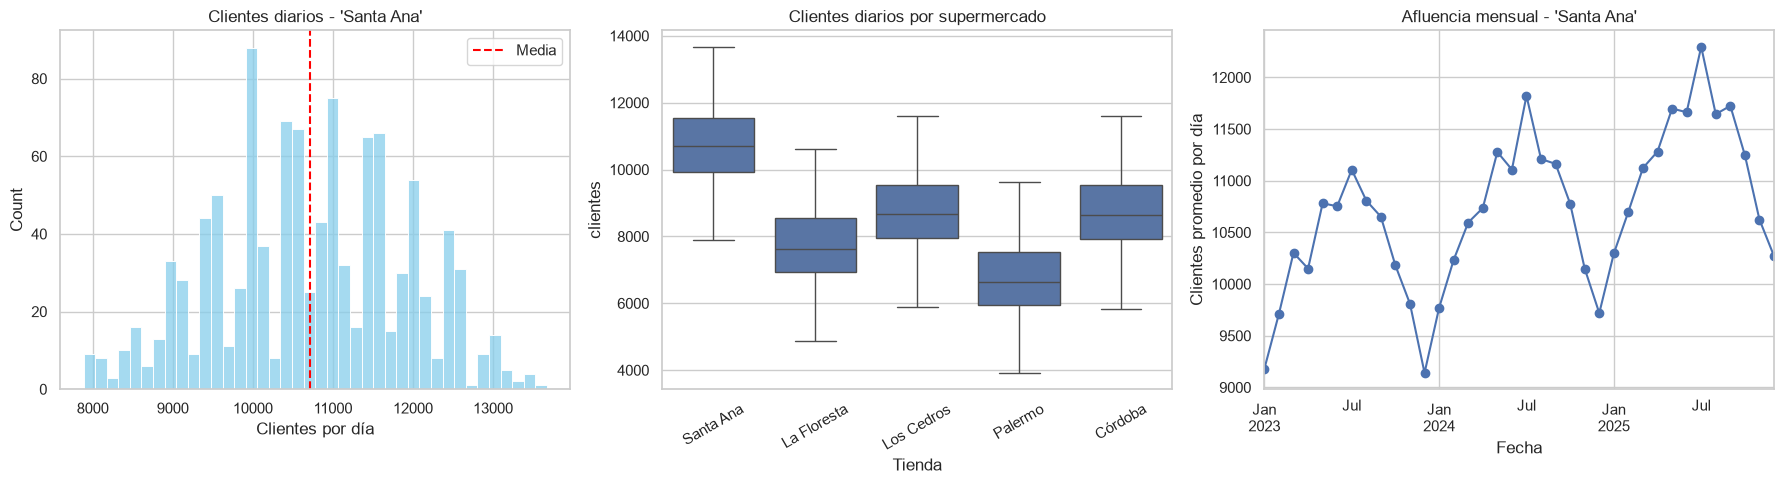

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

santa_ana = df.loc[df["tienda"] == "Santa Ana", "clientes"]
sns.histplot(santa_ana, bins=40, color="skyblue", ax=axs[0])
axs[0].axvline(santa_ana.mean(), color="red", linestyle="--", label="Media")
axs[0].legend()
axs[0].set_title("Clientes diarios - 'Santa Ana'")
axs[0].set_xlabel("Clientes por día")

sns.boxplot(data=df, x="tienda", y="clientes", ax=axs[1])
axs[1].set_title("Clientes diarios por supermercado")
axs[1].set_xlabel("Tienda")
axs[1].tick_params(axis="x", rotation=30)

series_mensual = (
    df.loc[df["tienda"] == "Santa Ana"]
    .set_index("fecha")["clientes"]
    .resample("MS")
    .mean()
)
series_mensual.plot(ax=axs[2], marker="o")
axs[2].set_title("Afluencia mensual - 'Santa Ana'")
axs[2].set_xlabel("Fecha")
axs[2].set_ylabel("Clientes promedio por día")

fig.tight_layout()
plt.show()

## 2. (2.5 puntos) Intervalos de confianza empíricos para 'Santa Ana'

Con base en los datos generados, determinen intervalos de confianza empíricos para el supermercado ’Santa Ana’ en cada mes, para significancias del 95 % y el 99 %.

In [37]:
def intervalo_t(muestra, confianza):
    """IC paramétrico (t de Student): media ± t(n-1, 1-α/2) · s/√n (σ desconocida)"""
    n = muestra.size
    media = float(np.mean(muestra))
    error = float(np.std(muestra, ddof=1) / np.sqrt(n))
    inferior, superior = st.t.interval(confianza, df=n - 1, loc=media, scale=error)
    return float(inferior), float(superior)

def intervalo_bootstrap(muestra, confianza, *, rng, n_remuestras=10_000):
    """IC empírico: remuestreo con reposición y percentiles α/2, 1-α/2"""
    remuestras = rng.choice(muestra, size=(n_remuestras, muestra.size), replace=True)
    medias = remuestras.mean(axis=1)
    inferior, superior = np.percentile(
        medias, [100 * (1 - confianza) / 2, 100 * (1 + confianza) / 2]
    )
    return float(inferior), float(superior)

def intervalos_por_mes(df, tienda, *, metodo="t", confianzas=(0.95, 0.99), seed=42):
    """Un IC por mes (filas) y por confianza (columnas)"""
    rng = np.random.default_rng(seed)  # para que el bootstrap no cambie
    filas = []

    for numero, nombre in MESES.items():
        muestra = df.loc[
            (df["tienda"] == tienda) & (df["mes"] == numero), "clientes"
        ].to_numpy(dtype=float)
        fila = {
            "n": muestra.size,
            "media": float(np.mean(muestra)),
            "desvio_estandar": float(np.std(muestra, ddof=1)),
        }
        for confianza in confianzas:
            if metodo == "t":
                inferior, superior = intervalo_t(muestra, confianza)
            else:
                inferior, superior = intervalo_bootstrap(muestra, confianza, rng=rng)
            sufijo = int(confianza * 100)  # 95/99 -> nombre de columna
            fila[f"ic{sufijo}_inf"] = inferior
            fila[f"ic{sufijo}_sup"] = superior
        fila["mes"] = nombre
        filas.append(fila)

    return pd.DataFrame(filas).set_index("mes")

ic_t = intervalos_por_mes(df, "Santa Ana", metodo="t")
ic_bootstrap = intervalos_por_mes(df, "Santa Ana", metodo="bootstrap")

In [38]:
print("a) Método paramétrico (t de Student), IC para la media:")
print(ic_t.round(2).to_string())

print("\nb) Método empírico (bootstrap por percentiles, 10 000 remuestras):")
print(ic_bootstrap.round(2).to_string())

# Los dos métodos dan casi lo mismo (con ~90 datos la t es ≈ normal)
# y el IC del 99 % es siempre más ancho que el del 95 %.

a) Método paramétrico (t de Student), IC para la media:
             n     media  desvio_estandar  ic95_inf  ic95_sup  ic99_inf  ic99_sup
mes                                                                              
Enero       93   9748.75          1042.96   9533.96   9963.55   9464.28  10033.22
Febrero     85  10215.85           997.28  10000.74  10430.96   9930.75  10500.95
Marzo       93  10673.53           976.08  10472.51  10874.55  10407.30  10939.75
Abril       90  10722.57          1039.23  10504.90  10940.23  10434.22  11010.91
Mayo        93  11252.61           989.23  11048.88  11456.34  10982.80  11522.43
Junio       90  11174.34          1001.94  10964.49  11384.20  10896.35  11452.34
Julio       93  11741.48          1047.58  11525.74  11957.23  11455.75  12027.21
Agosto      93  11220.40           987.04  11017.12  11423.68  10951.18  11489.62
Septiembre  90  11179.73          1027.86  10964.45  11395.01  10894.54  11464.92
Octubre     93  10734.99          1022.66 

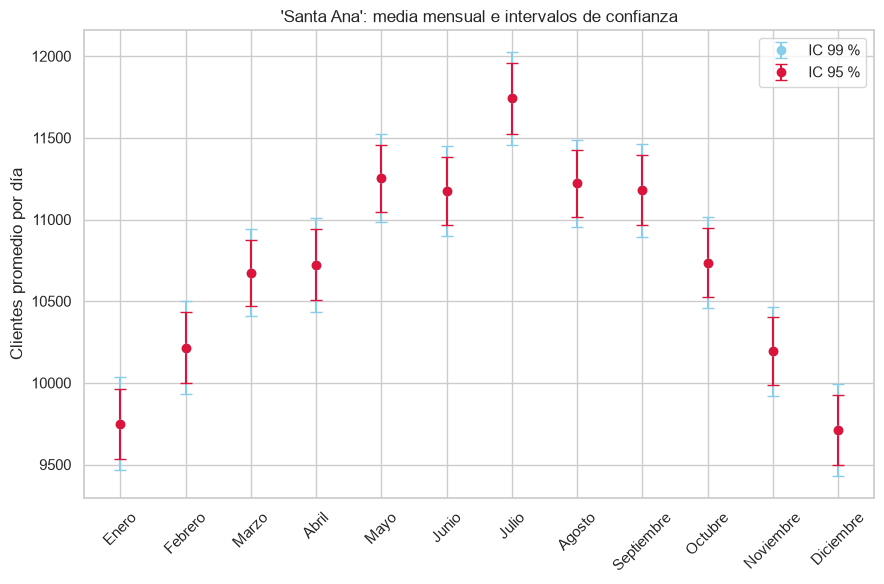

In [39]:
# Medias mensuales con sus IC:
# el de 99 % (azul, ancho) y el de 95 % (rojo, angosto)

fig, ax = plt.subplots(figsize=(9, 6))
meses_ordenados = list(MESES.values())
errores = ic_t.loc[meses_ordenados]
x = np.arange(len(meses_ordenados))

ax.errorbar(
    x,
    errores["media"],
    yerr=[
        errores["media"] - errores["ic99_inf"],
        errores["ic99_sup"] - errores["media"],
    ],
    fmt="o",
    capsize=4,
    color="skyblue",
    label="IC 99 %",
)
ax.errorbar(
    x,
    errores["media"],
    yerr=[
        errores["media"] - errores["ic95_inf"],
        errores["ic95_sup"] - errores["media"],
    ],
    fmt="o",
    capsize=4,
    color="crimson",
    label="IC 95 %",
)
ax.set_xticks(x, meses_ordenados, rotation=45)
ax.set_ylabel("Clientes promedio por día")
ax.set_title("'Santa Ana': media mensual e intervalos de confianza")
ax.legend()
fig.tight_layout()
plt.show()

# Intervalos muy angostos: con ~90 observaciones por mes el promedio se
# estima con buena precisión (el error cae con √n).

## 3. (2.5 puntos) ANOVA

De igual manera, realicen pruebas ANOVA para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del 95 %.

In [40]:
# H0: el número esperado de clientes es igual en todas las tiendas
# H1: al menos una difiere
# Se rechaza H0 si p-valor < 0.05
#
# k = 5 grupos
# n = 5480 (1096 días x 5 tiendas)
#
# df entre = k - 1 = 4
# df dentro = n - k = 5475
#
# F = (SSB / (k-1)) / (SSW / (n-k)): bajo H0 ≈ 1, si alguna media difiere F > 1

grupos = [
    df.loc[df["tienda"] == tienda, "clientes"].to_numpy(dtype=float)
    for tienda in TIENDAS
]
f_statistic, p_valor = st.f_oneway(*grupos)

k = len(grupos)
n_total = sum(g.size for g in grupos)
print("H0: el número esperado de clientes es igual en todas las tiendas.")
print(f"F = {f_statistic:.2f} (df entre = {k - 1}, df dentro = {n_total - k})")
print(f"p-valor = {p_valor:.3e}")
if p_valor < 0.05:
    print("Se rechaza H0: al menos una tienda tiene un número esperado de clientes distinto.")
else:
    print("No hay evidencia suficiente para rechazar H0.")

# F enorme y p ≈ 0 => rechazo, como era esperable (efectos de 1000 a 5000)

H0: el número esperado de clientes es igual en todas las tiendas.
F = 1723.50 (df entre = 4, df dentro = 5475)
p-valor = 0.000e+00
Se rechaza H0: al menos una tienda tiene un número esperado de clientes distinto.


## 4. (2.5 puntos) Tienda con mayor y menor promedio + prueba de hipótesis

Finalmente, identifiquen la tienda con mayor promedio y la tienda con menor promedio de clientes y realicen una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.

In [41]:
promedios = {
    tienda: float(
        np.mean(df.loc[df["tienda"] == tienda, "clientes"].to_numpy(dtype=float))
    )
    for tienda in TIENDAS
}
print("Promedio de clientes diarios por tienda:")
print(pd.Series(promedios).sort_values(ascending=False).round(2).to_string())

tienda_max = max(promedios, key=lambda t: promedios[t])
tienda_min = min(promedios, key=lambda t: promedios[t])

# H0: μ_max = μ_min
# Usamos t de Welch (equal_var=False): no asume varianzas iguales, y acá no lo son (Poisson: varianza = media)
# Datos: n1 = n2 = 1096 días; t = (x̄1-x̄2) / √(s1²/n1 + s2²/n2)
a = df.loc[df["tienda"] == tienda_max, "clientes"].to_numpy(dtype=float)
b = df.loc[df["tienda"] == tienda_min, "clientes"].to_numpy(dtype=float)
t_stat, p_ab = st.ttest_ind(a, b, equal_var=False)

print(f"\nTienda con mayor promedio : {tienda_max} ({promedios[tienda_max]:.2f})")
print(f"Tienda con menor promedio : {tienda_min} ({promedios[tienda_min]:.2f})")
print(f"Diferencia de medias      : {promedios[tienda_max] - promedios[tienda_min]:.2f}")

print("\nH0: la diferencia entre ambas medias es igual a cero.")
print(f"t = {t_stat:.2f}, p-valor = {p_ab:.3e}")
if p_ab < 0.05:
    print("Se rechaza H0: la diferencia es distinta de cero.")
else:
    print("No hay evidencia suficiente para rechazar H0.")

efecto_max = max(EFECTO_TIENDA.items(), key=lambda item: item[1])[0]
efecto_min = min(EFECTO_TIENDA.items(), key=lambda item: item[1])[0]
print(f"\nTienda con mayor efecto en el modelo : {efecto_max} ({EFECTO_TIENDA[efecto_max]})")
print(f"Tienda con menor efecto en el modelo : {efecto_min} ({EFECTO_TIENDA[efecto_min]})")
if tienda_max == efecto_max and tienda_min == efecto_min:
    print("Las tiendas identificadas SÍ coinciden con las de mayor y menor efecto.")
else:
    print("Las tiendas identificadas NO coinciden con las de mayor y menor efecto.")

# t = 79.20, p ≈ 0 => sa rechaza H0:
# la diferencia no es cero (y por el signo, Santa Ana > Palermo, como en los efectos)

Promedio de clientes diarios por tienda:
Santa Ana      10716.55
Los Cedros      8717.11
Córdoba         8714.89
La Floresta     7712.86
Palermo         6718.30

Tienda con mayor promedio : Santa Ana (10716.55)
Tienda con menor promedio : Palermo (6718.30)
Diferencia de medias      : 3998.24

H0: la diferencia entre ambas medias es igual a cero.
t = 79.20, p-valor = 0.000e+00
Se rechaza H0: la diferencia es distinta de cero.

Tienda con mayor efecto en el modelo : Santa Ana (5000)
Tienda con menor efecto en el modelo : Palermo (1000)
Las tiendas identificadas SÍ coinciden con las de mayor y menor efecto.
